正在读取软件包列表...
Failed to install Times New Roman font: Command 'apt-get update && apt-get install -y ttf-mscorefonts-installer fontconfig && fc-cache -f -v' returned non-zero exit status 100.
Using font: DejaVu Serif


E: 无法打开锁文件 /var/lib/apt/lists/lock - open (13: 权限不够)
E: 无法对目录 /var/lib/apt/lists/ 加锁
W: 用 unlink 删除文件 /var/cache/apt/pkgcache.bin 出错 - RemoveCaches (13: 权限不够)
W: 用 unlink 删除文件 /var/cache/apt/srcpkgcache.bin 出错 - RemoveCaches (13: 权限不够)


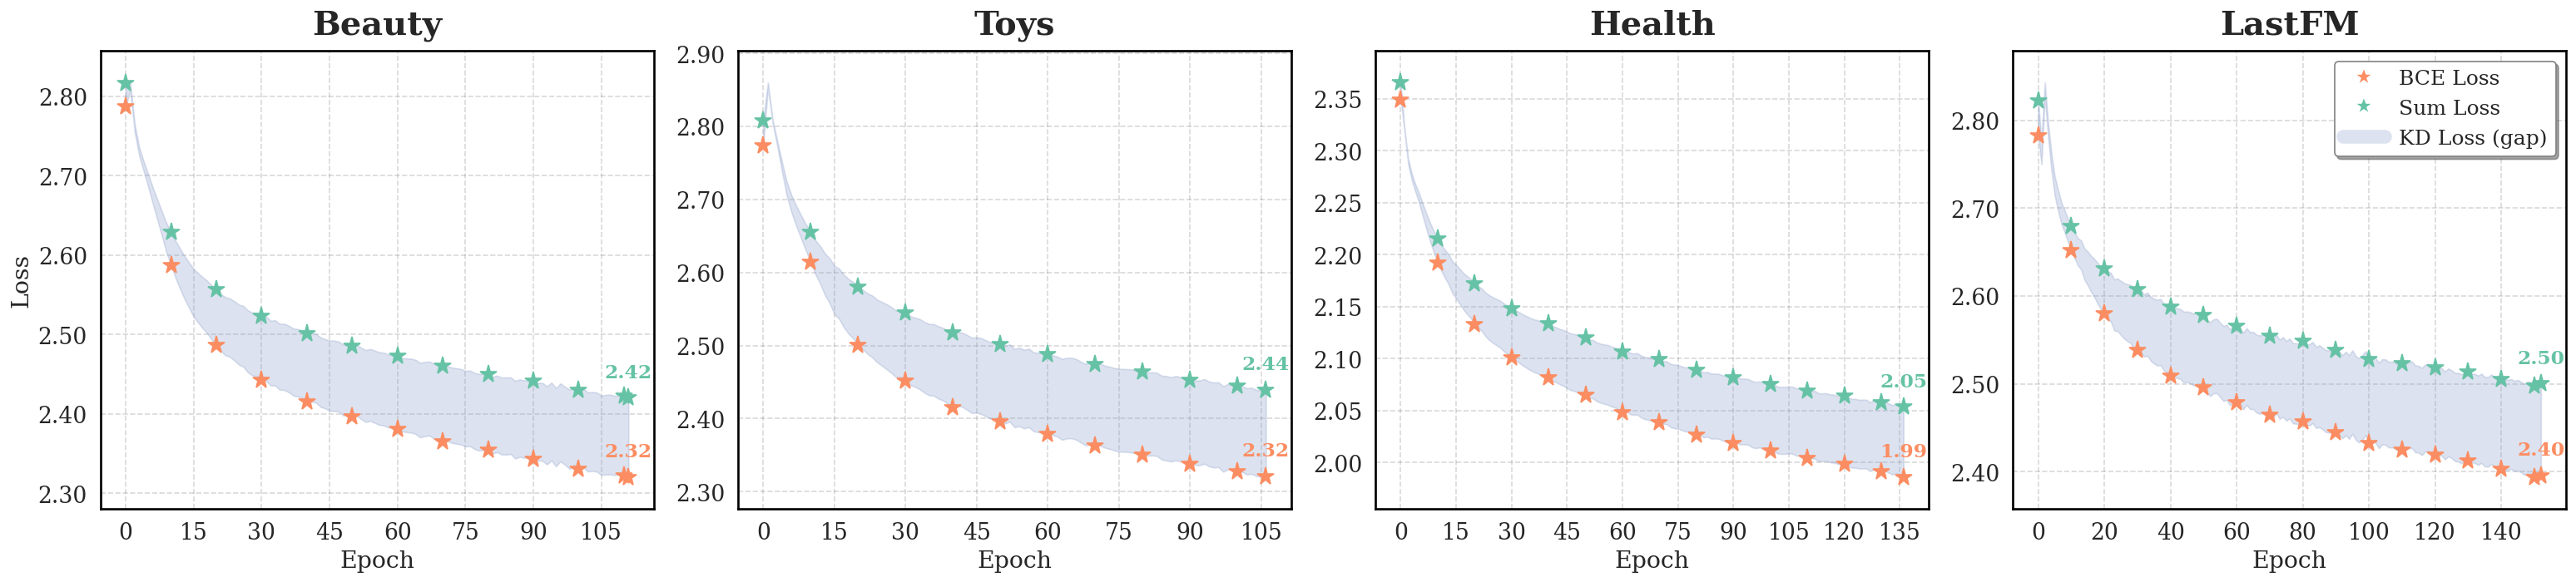

In [28]:
# 安装并检查 Times New Roman 字体
import sys
import subprocess

def install_ttf_fonts():
    try:
        # For Linux - install Microsoft fonts (including Times New Roman)
        if sys.platform.startswith("linux"):
            subprocess.check_call(
                "apt-get update && apt-get install -y ttf-mscorefonts-installer fontconfig && fc-cache -f -v",
                shell=True,
            )
        elif sys.platform.startswith("darwin"):
            print("On macOS, Times New Roman is usually pre-installed. If not, install via Microsoft Office or font websites.")
        elif sys.platform.startswith("win"):
            # Times New Roman is always present on Windows.
            pass
    except Exception as e:
        print("Failed to install Times New Roman font:", e)

install_ttf_fonts()

import matplotlib.font_manager as fm
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from matplotlib import rcParams
from matplotlib.lines import Line2D

# 检查 Times New Roman 是否可用，否则 fallback 到 DejaVuSerif
font_candidates = ['Times New Roman', 'TimesNewRoman', 'DejaVu Serif']
available_fonts = set(f.name for f in fm.fontManager.ttflist)
font_choice = None
for f in font_candidates:
    if f in available_fonts:
        font_choice = f
        break
if font_choice is None:
    print("Warning: Times New Roman font not found! Falling back to default serif font.")
    font_choice = 'serif'
else:
    print(f"Using font: {font_choice}")

# Set font for matplotlib and seaborn
rcParams['font.family'] = font_choice
sns.set_theme(style="whitegrid", font=font_choice, rc={"font.sans-serif": [font_choice], "font.family": "serif"})

datasets = ["Beauty", "Sports_and_Outdoors", "Toys_and_Games", "Health"]
# 各数据集的缩写名称（用于子图标题）
dataset_abbr = ["Beauty", "Toys", "Health", "LastFM"]

# 日志文件对应每个数据集顺序
log_files = [
    "/home/aizoo/data/workspace/ensemble_negatives/V2_Pro/TEST_KD/Beauty-SASRec-Mamba4Rec_a1.0_b1.0_l1.0_dwsb1.0_t0.0_k1_N100_kdt1.0_kdg0.01.log",
    "/home/aizoo/data/workspace/ensemble_negatives/V2_Pro/TEST_KD/Toys_and_Games-SASRec-Mamba4Rec_a1.0_b1.0_l1.0_dwsb1.0_t0.0_k1_N100_kdt1.0_kdg0.01.log",
    "/home/aizoo/data/workspace/ensemble_negatives/V2_Pro/TEST_KD/Health-SASRec-Mamba4Rec_a1.0_b1.0_l0.5_dwsb1.0_t0.0_k1_N100_kdt1.0_kdg0.01.log",
    "/home/aizoo/data/workspace/ensemble_negatives/V2_Pro/TEST_KD/LastFM-SASRec-Mamba4Rec_a1.0_b1.0_l1.0_dwsb1.0_t0.0_k1_N100_kdt1.0_kdg0.01.log"
]

pattern = re.compile(
    r"\{'epoch':\s*(\d+),\s*'avg_loss':\s*'([0-9\.eE+-]+)',\s*'avg_bpr_loss':\s*'([0-9\.eE+-]+)',\s*'avg_kd_loss':\s*'([0-9\.eE+-]+)'\}"
)

results = []
for log_file in log_files:
    epochs = []
    avg_losses = []
    avg_bpr_losses = []
    avg_kd_losses = []
    try:
        with open(log_file, "r") as f:
            for line in f:
                match = pattern.search(line)
                if match:
                    epoch = int(match.group(1))
                    avg_loss = float(match.group(2)) / 3   # 除以3
                    avg_bpr_loss = float(match.group(3)) / 3   # 除以3
                    avg_kd_loss = float(match.group(4)) / 3    # 除以3
                    epochs.append(epoch)
                    avg_losses.append(avg_loss)
                    avg_bpr_losses.append(avg_bpr_loss)
                    avg_kd_losses.append(avg_kd_loss)
    except Exception as e:
        print(f"{log_file} with error: {e}")
    results.append((epochs, avg_losses, avg_bpr_losses, avg_kd_losses))

fig, axs = plt.subplots(1, 4, figsize=(26, 6), dpi=120, sharey=False)  # 关键：sharey=False，每个图纵坐标独立

for idx, (ds, abbr, (epochs, avg_losses, avg_bpr_losses, avg_kd_losses)) in enumerate(zip(datasets, dataset_abbr, results)):
    ax = axs[idx]
    palette = sns.color_palette("Set2", 3)
    if not epochs:
        ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes, fontsize=16, color='gray', fontweight="bold", family=font_choice)
        ax.axis("off")
        continue

    star_indices = [i for i, ep in enumerate(epochs) if ep % 10 == 0]
    if 0 not in star_indices and len(epochs) > 0:
        star_indices = [0] + star_indices
    if len(epochs) > 1 and (len(epochs) - 1) not in star_indices:
        star_indices.append(len(epochs)-1)
    star_indices = sorted(set(star_indices))

    # 主曲线
    ax.plot(
        epochs, avg_bpr_losses,
        marker='', linestyle='', color=palette[1], linewidth=2.2, label="avg_bpr_loss"
    )
    ax.plot(
        epochs, avg_losses,
        marker='', linestyle='', color=palette[0], linewidth=2.2, label="avg_loss"
    )
    margin_fill = ax.fill_between(
        epochs, avg_bpr_losses, avg_losses,
        color=palette[2], alpha=0.30, label="avg_kd_loss (gap)"
    )
    # 星星点
    bpr_star = ax.plot(
        [epochs[i] for i in star_indices], [avg_bpr_losses[i] for i in star_indices],
        marker='*', markersize=13, linewidth=0, linestyle='None', color=palette[1], label="avg_bpr_loss", zorder=5
    )
    loss_star = ax.plot(
        [epochs[i] for i in star_indices], [avg_losses[i] for i in star_indices],
        marker='*', markersize=13, linewidth=0, linestyle='None', color=palette[0], label="avg_loss", zorder=5
    )



    # 为每个子图单独设置纵坐标范围
    all_values = avg_losses + avg_bpr_losses
    min_y = np.nanmin(all_values) if all_values else 0
    max_y = np.nanmax(all_values) if all_values else 1
    # 边距稍大一点，看起来舒服
    y_margin = (max_y - min_y) * 0.08 if max_y > min_y else 0.1
    ax.set_ylim(min_y - y_margin, max_y + y_margin)

    # 用缩写作为子图标题（加大标题字体）
    ax.set_title(f"{abbr}", fontsize=24, fontweight='bold', pad=12, family=font_choice)
    # 加大坐标轴标题字体
    ax.set_xlabel("Epoch", fontsize=17, family=font_choice)
    if idx == 0:
        ax.set_ylabel("Loss", fontsize=17, family=font_choice)

    # 加大坐标轴刻度值字体
    ax.tick_params(axis='both', which='major', labelsize=16)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontname(font_choice)

    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    # gird透明度高一点
    ax.grid(axis='y', color='grey', alpha=0.30, linestyle='--', linewidth=1)
    ax.grid(axis='x', color='grey', alpha=0.30, linestyle='--', linewidth=1)

    # 强制显示上下左右四个坐标轴且为黑色
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(1.6)
        ax.spines[spine].set_color('black')   # 坐标轴颜色设为黑色

    # Only display legend in the last subplot (rightmost)
    if idx == 3:
        # 图例元素：曲线与星星+margin(kd gap)
        star_legend_elements = [
            Line2D([0], [0], marker='*', color='w', markerfacecolor=palette[1], markersize=14, linestyle='None', label='BCE Loss'),
            Line2D([0], [0], marker='*', color='w', markerfacecolor=palette[0], markersize=14, linestyle='None', label='Sum Loss'),
            Line2D([0], [0], linestyle='-', color=palette[2], linewidth=10, alpha=0.30, label='KD Loss (gap)')  # Use thick line as patch for fill_between
        ]
        # 图例顺序: kd_loss在下面
        legend = ax.legend(handles=star_legend_elements, loc='upper right', fontsize=15, frameon=True, fancybox=True, shadow=True, handletextpad=0.7)
        legend.get_frame().set_facecolor('white')       # 图例背景改为白色
        legend.get_frame().set_alpha(1.0)               # 透明度为不透明
        legend.get_frame().set_edgecolor('grey')        # 灰色的边框
        for text in legend.get_texts():
            text.set_fontname(font_choice)
    # Annotate last star point： 末尾的数字放在最后一个星星点（bpr星星）正上方一点
    if epochs and avg_bpr_losses and avg_losses and star_indices:
        last_star_idx = star_indices[-1]
        last_star_epoch = epochs[last_star_idx]
        last_star_bpr = avg_bpr_losses[last_star_idx]
        # 在最后一个星星点正上方一点
        ax.text(
            last_star_epoch,
            last_star_bpr + ((max_y-min_y)*0.04 if max_y > min_y else 0.03),
            f"{last_star_bpr:.2f}",
            va='bottom', ha='center', fontsize=14,
            color=palette[1], fontweight='bold', family=font_choice
        )
        # 给所有绿色星星点（avg_loss）标数字
    if epochs and avg_losses and star_indices:
        # 给最后一个绿色星星点（avg_loss）标数字
        last_star_idx = star_indices[-1]
        last_star_epoch = epochs[last_star_idx]
        last_star_loss = avg_losses[last_star_idx]
        ax.text(
            last_star_epoch,
            last_star_loss + ((max_y-min_y)*0.04 if max_y > min_y else 0.03),
            f"{last_star_loss:.2f}",
            va='bottom', ha='center', fontsize=14,
            color=palette[0], fontweight='bold', family=font_choice
        )
          
# plt.suptitle("Training Loss Trend Across Datasets", fontsize=24, fontweight='bold', y=1.04, family=font_choice)
plt.tight_layout()
plt.show()
